**1.0 INITIAL**

In [445]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [446]:
df = pd.read_csv("../data/titanic3.csv")

In [447]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [448]:
df.shape

(1309, 14)

In [449]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 143.3 KB


In [450]:
df = df[['pclass', 'sex', 'age', 'sibsp','parch', 'fare', 'embarked', 'survived']]

In [451]:
df.head(2)

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.00,0,0,211.3375,S,1
1,1,male,0.92,1,2,151.5500,S,1


**1.1 SUMMARY STATISTICS**

In [452]:
numerics = ['pclass', 'age', 'sibsp', 'parch', 'fare']
X_numeric = df[numerics].copy()

In [453]:
non_numerics = ['sex', 'embarked']
X_cat = df[non_numerics].copy()

In [454]:
target = df['survived']

In [455]:
X_numeric.head(2)

,pclass,age,sibsp,parch,fare
0,1,29.00,0,0,211.3375
1,1,0.92,1,2,151.5500


In [456]:
X_cat.head(2)

,sex,embarked
0,female,S
1,male,S


In [457]:
numeric_stats = pd.DataFrame(columns=['mean', 'median', 'std', 'non-null-count', 'missing-count'], index=['pclass', 'age', 'sibsp', 'parch', 'fare'])

In [458]:
numeric_stats['mean'] = X_numeric.mean()
numeric_stats['median'] = X_numeric.median()
numeric_stats['std'] = X_numeric.std()
numeric_stats['non-null-count'] = X_numeric.notna().sum()
numeric_stats['missing-count'] = X_numeric.isnull().sum()

**SUMMARY OF STATISTICS FOR THE NUMERICAL FEATURES**

In [459]:
numeric_stats

,mean,median,std,non-null-count,missing-count
pclass,2.294882,3.0000,0.837836,1309,0
age,29.881138,28.0000,14.413493,1046,263
sibsp,0.498854,0.0000,1.041658,1309,0
parch,0.385027,0.0000,0.865560,1309,0
fare,33.295479,14.4542,51.758668,1308,1


**SUMMARY OF STATISTICS FOR THE CATEGORICAL FEATURE: sex**

In [460]:
sex_counts = (
    X_cat["sex"].value_counts(dropna=False).rename_axis("category").reset_index(name="count")
)

sex_counts

,category,count
0,male,843
1,female,466


**SUMMARY OF STATISTICS FOR THE CATEGORICAL FEATURE: embarked**

In [461]:
embarked_counts = (
    X_cat["embarked"].value_counts(dropna=False).rename_axis("category").reset_index(name="count")
)

embarked_counts

,category,count
0,S,914
1,C,270
2,Q,123
3,NaN,2


**FINAL TABLE: SUMMARY OF STATISTICS FOR CATEGORICAL FEATURES**

In [462]:
sex_counts["feature"] = "sex"
embarked_counts["feature"] = "embarked"

categorical_stats = pd.concat(
    [sex_counts, embarked_counts],
    ignore_index=True
)

categorical_stats = categorical_stats[
    ["feature", "category", "count"]
]

categorical_stats

,feature,category,count
0,sex,male,843
1,sex,female,466
2,embarked,S,914
3,embarked,C,270
4,embarked,Q,123
5,embarked,NaN,2


**1.2 TARGET DISTRIBUTION AND CLASS BALANCE**

In [463]:
target.value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [464]:
target.value_counts(normalize=True).round(2)

survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Mildly imbalanced -> The non-survival class represents about 62% of the whole. While it is more frequent, both classes still have sufficient representation.

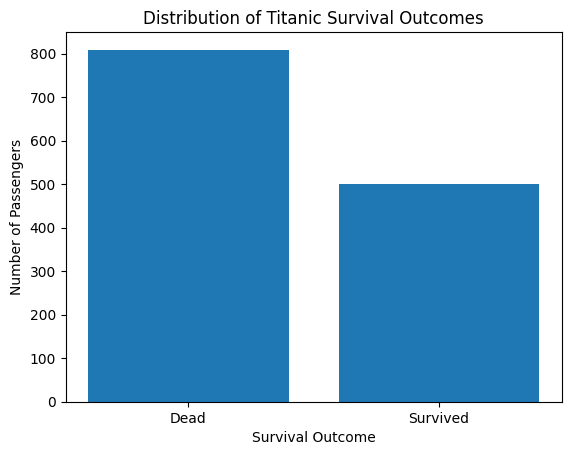

In [465]:
target_counts = df["survived"].value_counts().sort_index()
labels = ["Dead", "Survived"]

plt.bar(labels, target_counts.values)

plt.title("Distribution of Titanic Survival Outcomes")
plt.xlabel("Survival Outcome")
plt.ylabel("Number of Passengers")

plt.savefig(
    "../figures/target_distribution.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**1.3 THREE FEATURE AND TARGET INVESTIGATION**

**#1 -> sex**

In [466]:
sex_survival = pd.crosstab(X_cat["sex"], target, normalize="index")
sex_survival

survived,0,1
sex,,
female,0.272532,0.727468
male,0.809015,0.190985


Female passengers had a substantially higher survival proportion than male passengers.

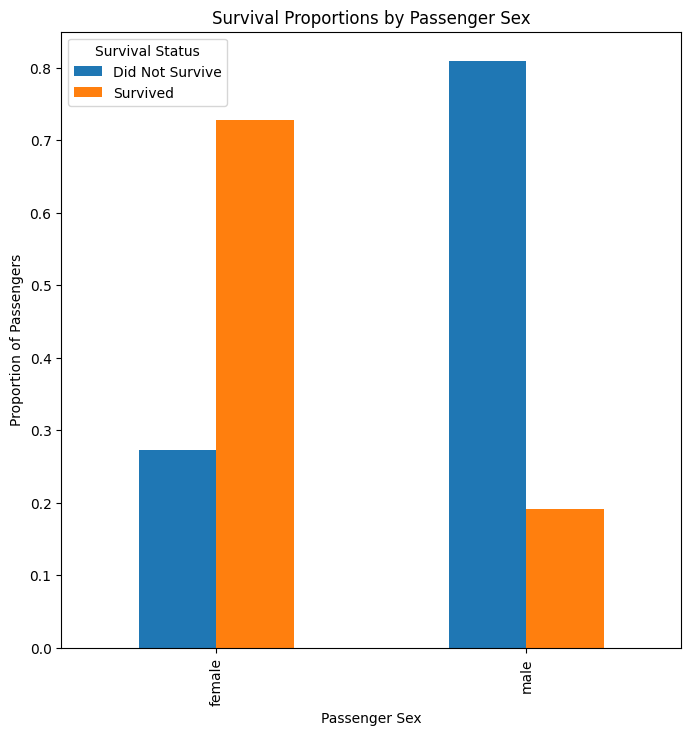

In [467]:
ax = sex_survival.plot(
    kind="bar", figsize=(8, 8)
)

ax.set_title("Survival Proportions by Passenger Sex")
ax.set_xlabel("Passenger Sex")
ax.set_ylabel("Proportion of Passengers")

ax.legend(
    title="Survival Status",
    labels=["Did Not Survive", "Survived"]
)

plt.savefig(
    "../figures/sex_vs_survived.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**#2 -> pclass**

In [468]:
pclass_survival = pd.crosstab(X_numeric["pclass"], target, normalize="index")
pclass_survival

survived,0,1
pclass,,
1,0.380805,0.619195
2,0.570397,0.429603
3,0.744711,0.255289


We can observe that, survival proportion decreases as the pclass changes from 1 to 3.

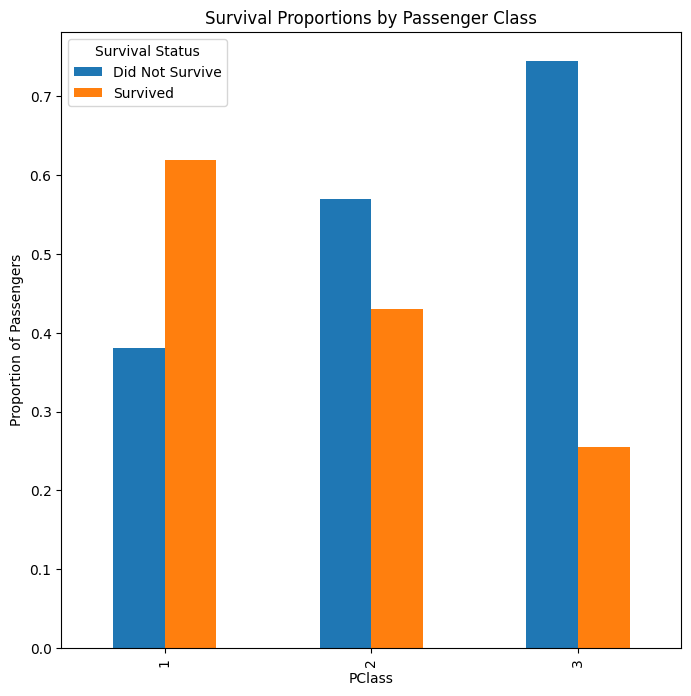

In [469]:
ax = pclass_survival.plot(
    kind="bar", figsize=(8, 8)
)

ax.set_title("Survival Proportions by Passenger Class")
ax.set_xlabel("PClass")
ax.set_ylabel("Proportion of Passengers")

ax.legend(
    title="Survival Status",
    labels=["Did Not Survive", "Survived"]
)

plt.savefig(
    "../figures/pclass_vs_survived.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**#3 -> fare**

In [470]:
fare_not_survived = df.loc[df["survived"] == 0, "fare"].dropna()
fare_survived = df.loc[df["survived"] == 1, "fare"].dropna()

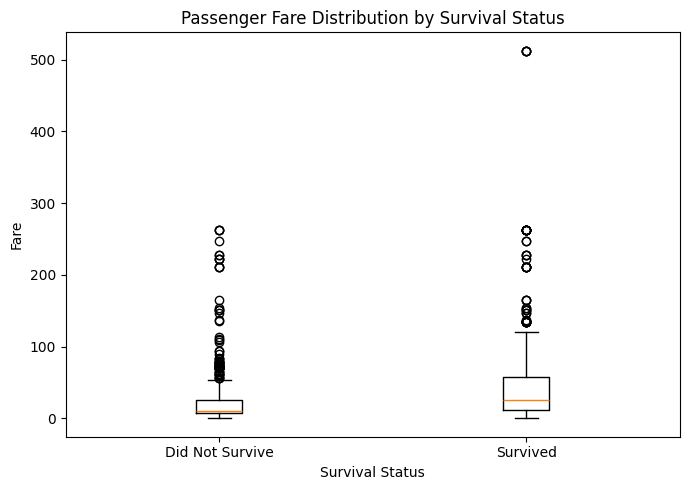

In [471]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [fare_not_survived, fare_survived],
    tick_labels=["Did Not Survive", "Survived"]
)

plt.title("Passenger Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")

plt.tight_layout()

plt.savefig(
    "../figures/fare_vs_survived.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Both groups have quite a few high-fare outliers. However, survived passengers had higher fares generally.

**1.4 Missing-data strategy.**

In [472]:
X_numeric.isna().sum()

pclass      0
age       263
sibsp       0
parch       0
fare        1
dtype: int64

In [473]:
X_cat.isna().sum()

sex         0
embarked    2
dtype: int64

Missing Values Report:
 - age -> 263 values
 - fare -> 1 value
 - embarked -> 2 values

In [474]:
missing = pd.DataFrame(columns=['missing_count', 'missing_percentage'], index=['age', 'fare', 'embarked'])

missing['missing_count'] = [X_numeric['age'].isna().sum(), X_numeric['fare'].isna().sum(), X_cat['embarked'].isna().sum()]
missing['missing_percentage'] = np.round(missing['missing_count'] / len(df) * 100, 2)

In [475]:
missing

,missing_count,missing_percentage
age,263,20.09
fare,1,0.08
embarked,2,0.15


Our strategies will be:
1. age -> Since the percentage is lower than 30, we should fill this numeric column with the median. Median imputation was used for age and fare because the median is less sensitive to extreme values than the mean. This is particularly appropriate for fare, whose box plot shows several high-value outliers.
2. fare -> Since the percentage is lower than 30, we should fill this numeric column with the median
3. embarked -> Since the percentage is lower than 30, we should fill this categoric column with the mode. For categorical features, we cannot find an average or median. The best strategy would be to fill with the most-repeated value.

In [476]:
# Exploratory imputation for the EDA feature matrix.
# Numeric columns use the median because it is robust to outliers.
X_numeric['age'] = X_numeric['age'].fillna(X_numeric['age'].median())
X_numeric['fare'] = X_numeric['fare'].fillna(X_numeric['fare'].median())

# The categorical column uses its most frequent value
X_cat['embarked'] = X_cat['embarked'].fillna(X_cat['embarked'].mode()[0])

In [477]:
print("Numeric missing values:")
print(X_numeric.isna().sum())

print("\nCategorical missing values:")
print(X_cat.isna().sum())

Numeric missing values:
pclass    0
age       0
sibsp     0
parch     0
fare      0
dtype: int64

Categorical missing values:
sex         0
embarked    0
dtype: int64


No selected column was dropped because none exceeded the 30% missingness threshold.

The full-dataset imputations in this notebook are used to demonstrate the exploratory feature-matrix construction. In the evaluation pipeline, imputation values will be calculated from the training subset only and then applied unchanged to the validation and test subsets to avoid leakage.

**1.5 Encoding and final feature matrix.**

We have two categorical features: embarked and sex.

Both of them are unordered, so the strategy to use is one-hot encoding.
Instead of dropping the first columns by (drop_first=True), all one-hot columns were retained because KNN uses distances directly. Dropping a reference category could make some unordered category pairs appear closer than others.

In [478]:
X_cat = pd.get_dummies(X_cat, dtype=int)
# dtype=int -> the new features will be numeric

We merge the categorical and numeric tables to produce a final feature table.

In [479]:
X_final = X_numeric.merge(X_cat, left_index=True, right_index=True)

In [480]:
X_final.head(2)

,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1,29.00,0,0,211.3375,1,0,0,0,1
1,1,0.92,1,2,151.5500,0,1,0,0,1


In [481]:
target.head(2)

0    1
1    1
Name: survived, dtype: int64

In [482]:
X_final.shape

(1309, 10)

**Eventually, we have 10 features for the model. the shape is (1309, 10). X_final is our final feature dataframe and target is showing whether the passenger survived or not.**

In [483]:
print("Feature-matrix shape:", X_final.shape)
print("Target shape:", target.shape)
print("Remaining missing values:", X_final.isna().sum().sum())
print("All feature columns numeric:", all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in X_final.dtypes
))

Feature-matrix shape: (1309, 10)
Target shape: (1309,)
Remaining missing values: 0
All feature columns numeric: True
